# Telco Customer Churn — End-to-End Analysis

**Objective:** Predict customer churn and estimate Customer Lifetime Value (CLV) for a telecom company, then translate model outputs into actionable business strategies.

**Dataset:** IBM Watson Telco Customer Churn (`WA_Fn-UseC_-Telco-Customer-Churn.csv`)  
**Target Variable:** `Churn` (binary: 1 = churned, 0 = retained)


## 1. Importing Libraries <a id='1'></a>

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Sklearn — preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Sklearn — model selection
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Sklearn — models
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# Sklearn — metrics
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    recall_score, precision_score, roc_curve,
    classification_report
)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost
from xgboost import XGBClassifier

# Suppress deprecation noise
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('ggplot')
sns.set(font_scale=1.1)

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Data Import & Initial Inspection <a id='2'></a>

In [2]:
data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {data.shape[0]:,} rows × {data.shape[1]} columns')
data.head()

Shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:

# TotalCharges is loaded as object due to blank strings → coerce to float
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Churn: Yes/No → 1/0
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

# Normalise 'No internet service' / 'No phone service' → 'No'
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

for c in addon_cols:
    data[c] = data[c].replace({'No internet service': 'No', 'No phone service': 'No'})

print('Missing values after type fixes:')
print(data.isnull().sum()[data.isnull().sum() > 0])

Missing values after type fixes:
TotalCharges    11
dtype: int64


## 3. Exploratory Data Analysis
### Target Distribution Before Filtering 

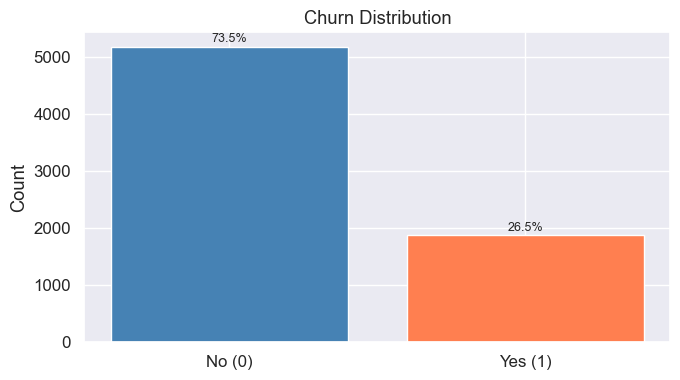

In [5]:
churn_counts = data['Churn'].value_counts()
churn_pct    = data['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['No (0)', 'Yes (1)'], churn_counts,
              color=['steelblue', 'coral'], edgecolor='white')
for bar, pct in zip(bars, churn_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_title('Churn Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


### 3b. Categorical Feature Distributions

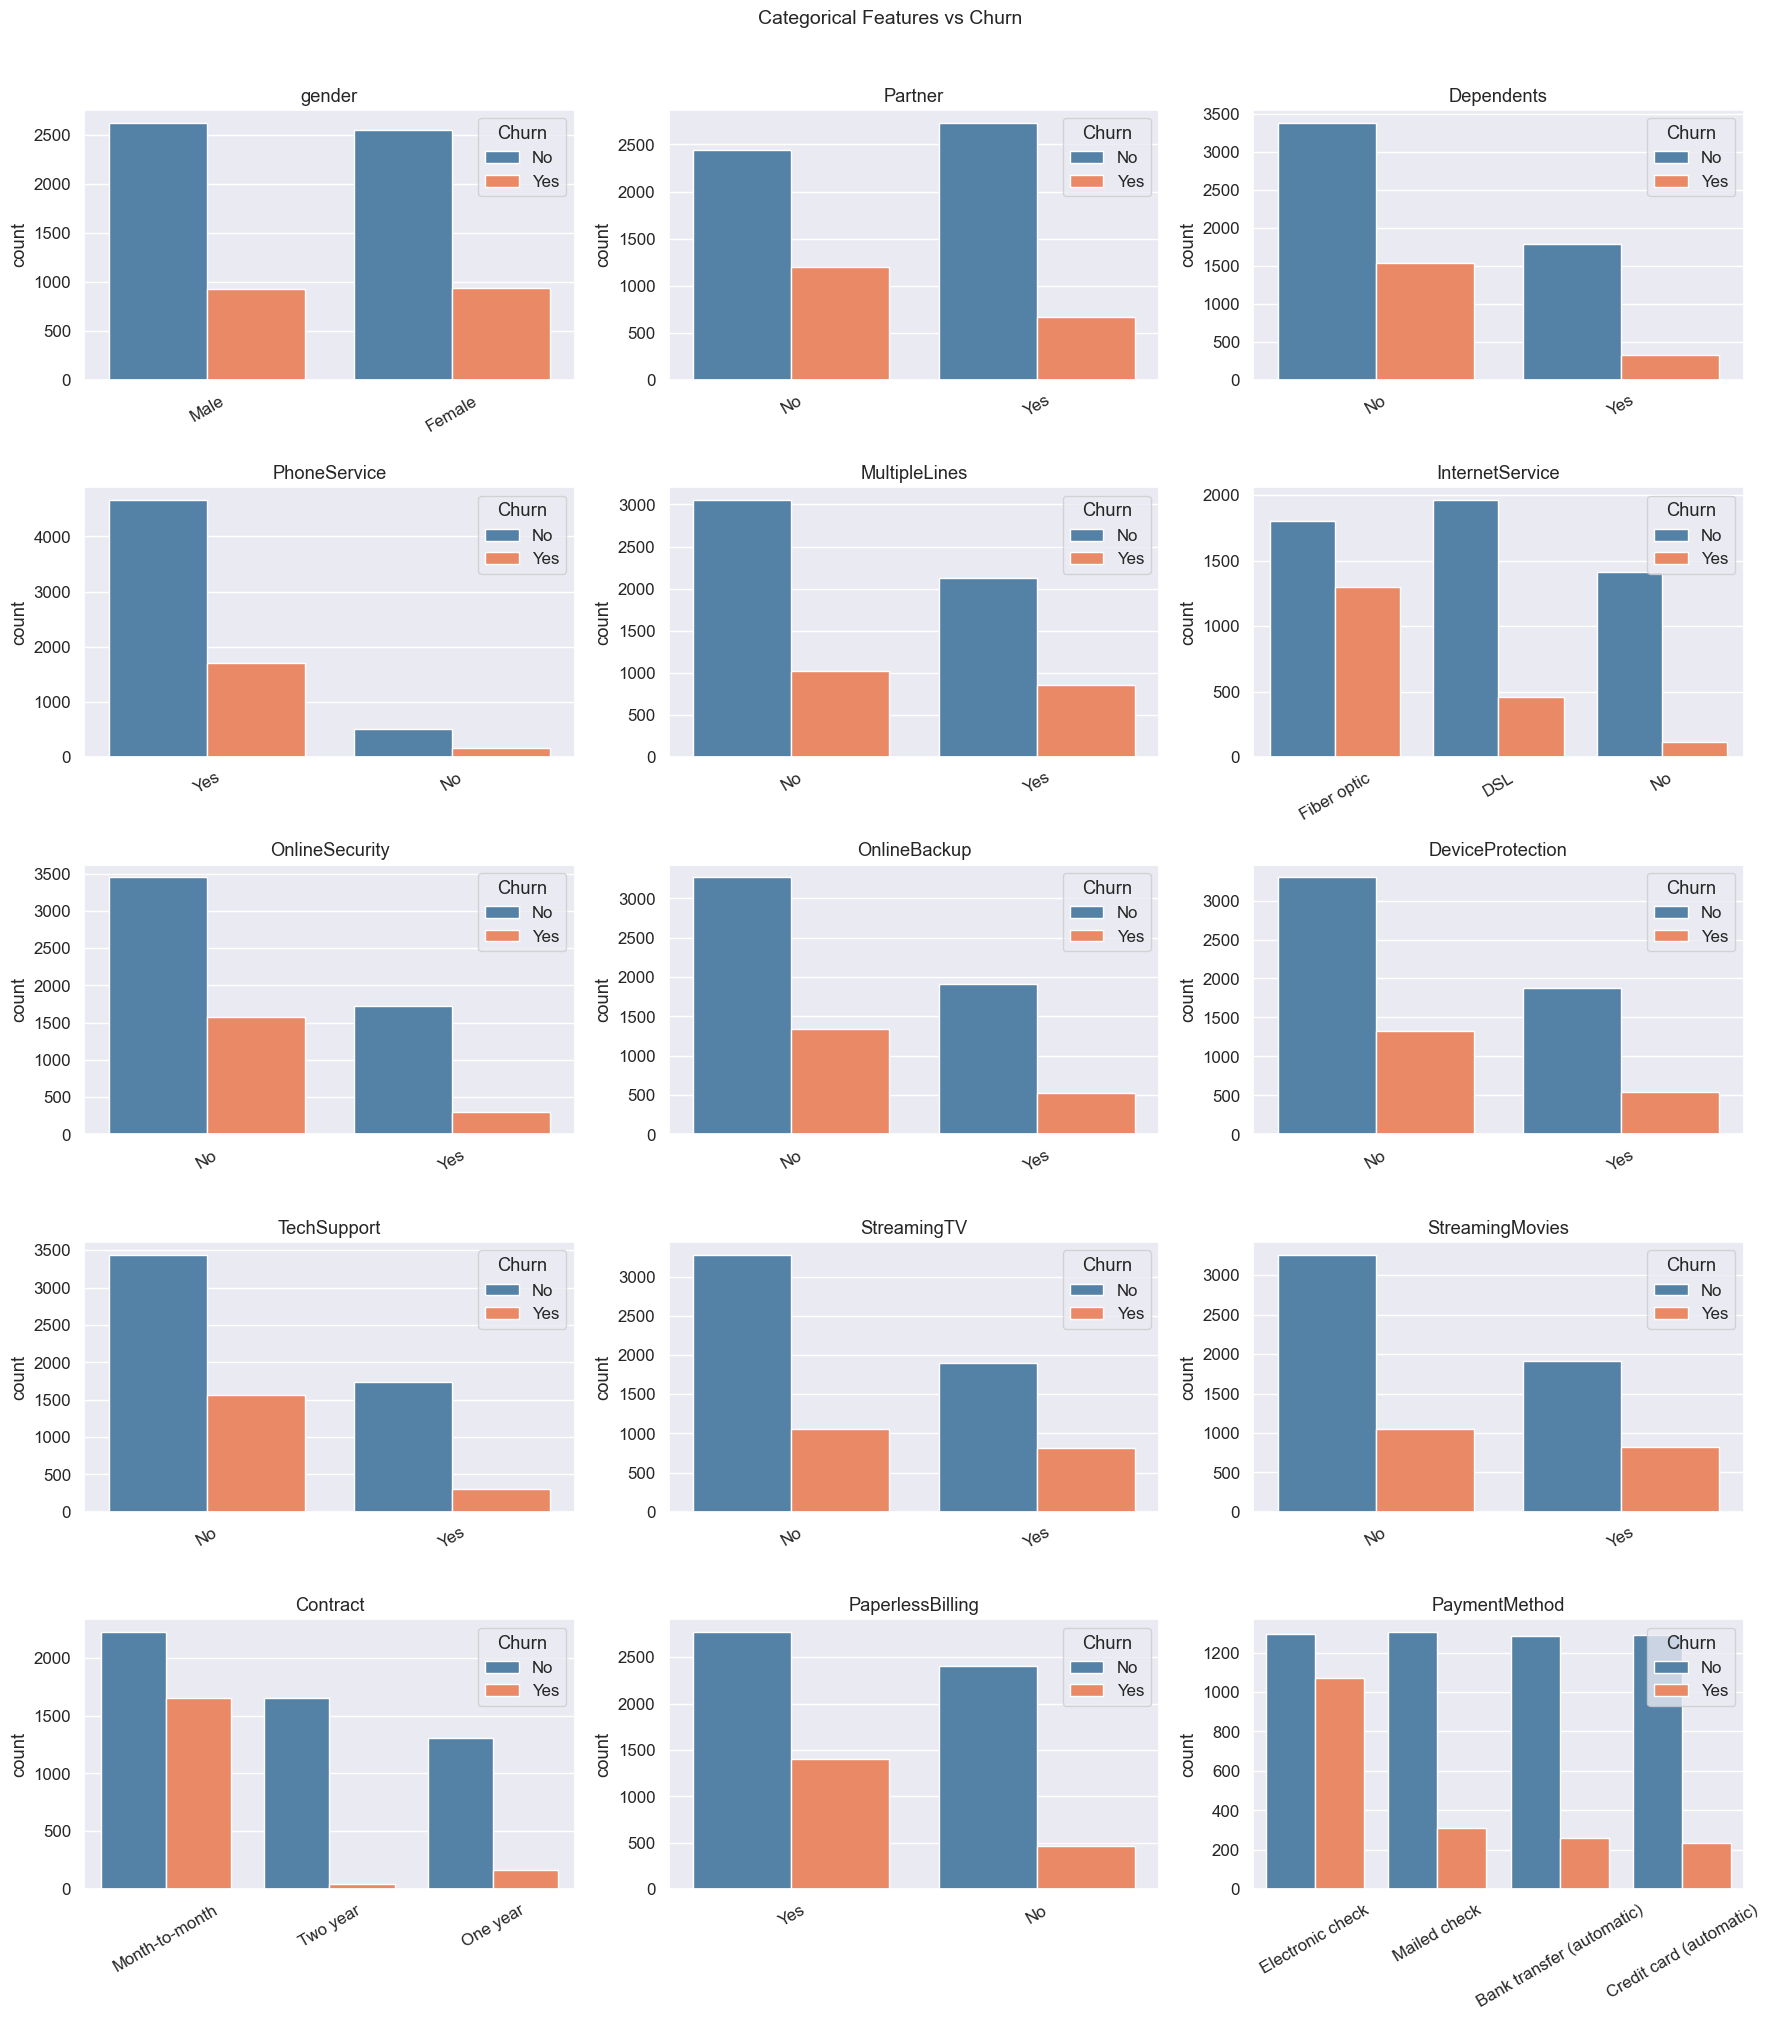

In [6]:
cat_eda_cols = data.select_dtypes(include='object').columns.drop('customerID').tolist()
n_cols = 3
n_rows = -(-len(cat_eda_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_eda_cols):
    order = data[col].value_counts().index
    sns.countplot(data=data, x=col, order=order, ax=axes[i],
                  hue='Churn', palette={0: 'steelblue', 1: 'coral'})
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Churn', labels=['No', 'Yes'])

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features vs Churn', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3c. Numeric Feature Distributions

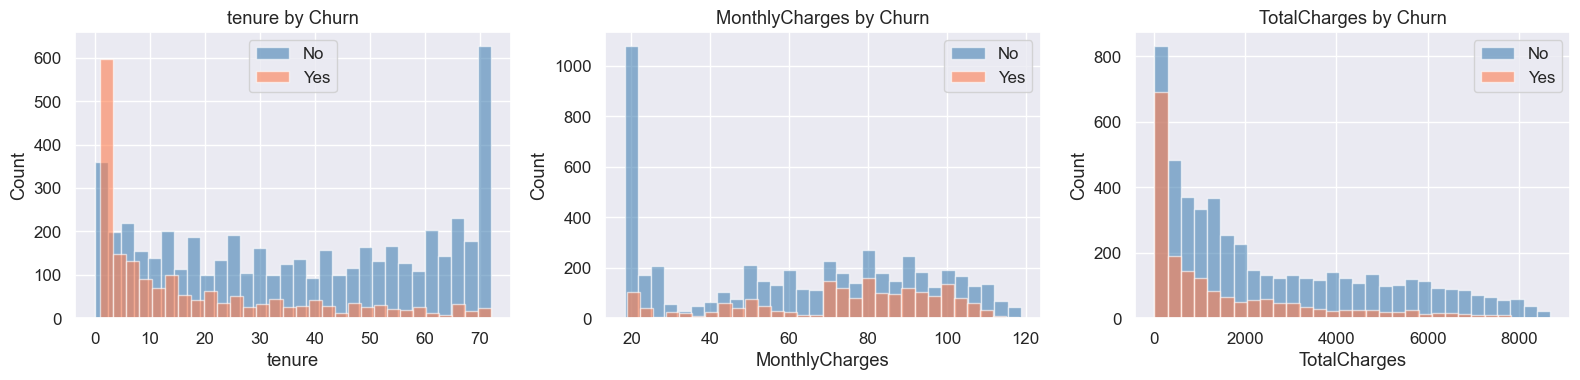

In [6]:
num_eda_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_eda_cols):
    ax.hist(data.loc[data['Churn']==0, col].dropna(), bins=30,
            alpha=0.6, label='No', color='steelblue')
    ax.hist(data.loc[data['Churn']==1, col].dropna(), bins=30,
            alpha=0.6, label='Yes',  color='coral')
    ax.set_title(f'{col} by Churn')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

### 3d. Churn Rates by Key Segments

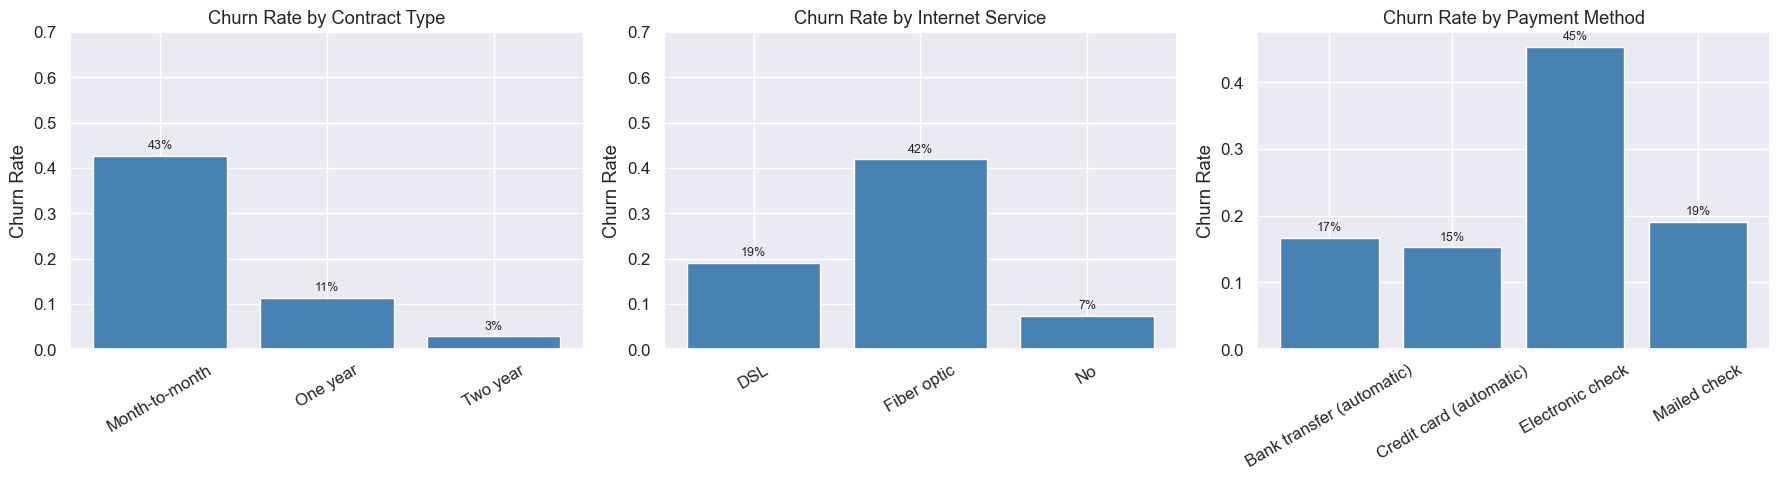

In [8]:
def plot_churn_rate(col, order=None, title=None, ax=None, ylim=(0, 0.7)):
    """Bar chart of churn rate for a categorical column."""
    if col not in data.columns:
        return
    rates = data.groupby(col)['Churn'].mean()
    if order:
        rates = rates.reindex(order)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(rates.index, rates.values, color='steelblue', edgecolor='white')
    ax.set_title(title or f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    if ylim:
        ax.set_ylim(*ylim)
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, rates.values):
        ax.annotate(f'{v:.0%}', (bar.get_x() + bar.get_width()/2, v),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                    textcoords='offset points')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_churn_rate('Contract',
                order=['Month-to-month', 'One year', 'Two year'],
                title='Churn Rate by Contract Type', ax=axes[0])
plot_churn_rate('InternetService',
                order=['DSL', 'Fiber optic', 'No'],
                title='Churn Rate by Internet Service', ax=axes[1])
plot_churn_rate('PaymentMethod',
                title='Churn Rate by Payment Method', ax=axes[2], ylim=None)
plt.tight_layout()
plt.show()

### Data Preparation & Feature Engineering 

We create a copy `dff` to preserve the original `data` for EDA, then add engineered features.

In [7]:
dff = data.copy()

# Keep only month-to-month customers
dff = dff[dff['Contract'] == 'Month-to-month'].copy()

# Sanity check
print(dff['Contract'].value_counts())
print("Filtered shape:", dff.shape)


print("Churn distribution after filtering:")
print(dff['Churn'].value_counts())

# ── Average monthly spend (avoids TotalCharges=0 for new customers) ─────────
dff['avg_monthly'] = dff.apply(
    lambda r: r['MonthlyCharges'] if r['tenure'] == 0 else r['TotalCharges'] / r['tenure'],
    axis=1
)

# ── Service adoption count ───────────────────────────────────────────────────
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies',
              'MultipleLines', 'PhoneService']
dff['addon_services_count'] = dff[addon_cols].apply(
    lambda col: (col == 'Yes').astype(int)
).sum(axis=1)

# ── Tenure group (categorical bucketing) ─────────────────────────────────────
dff['tenure_group'] = pd.cut(
    dff['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12m', '12-24m', '24-48m', '48-72m'],
    include_lowest=True
)

# ── Binary flags ─────────────────────────────────────────────────────────────
dff['is_fiber'] = (dff['InternetService'] == 'Fiber optic').astype(int)
dff['has_multiple_services'] = (dff['addon_services_count'] >= 3).astype(int)

# ── Spend efficiency features ────────────────────────────────────────────────
dff['charge_per_service'] = dff['MonthlyCharges'] / (dff['addon_services_count'] + 1)
dff['tenure_per_service'] = dff['tenure'] / (dff['addon_services_count'] + 1)
dff['charges_diff'] = dff['TotalCharges'] - dff['tenure'] * dff['MonthlyCharges']

# ── Drop ID column ───────────────────────────────────────────────────────────
dff.drop(columns=['customerID'], inplace=True, errors='ignore')

print(f'Feature-engineered shape: {dff.shape}')
dff.head(3)

Contract
Month-to-month    3875
Name: count, dtype: int64
Filtered shape: (3875, 21)
Churn distribution after filtering:
Churn
0    2220
1    1655
Name: count, dtype: int64
Feature-engineered shape: (3875, 28)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,Churn,avg_monthly,addon_services_count,tenure_group,is_fiber,has_multiple_services,charge_per_service,tenure_per_service,charges_diff
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,...,29.85,0,29.850,1,0-12m,0,0,14.9250,0.5,0.00
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,108.15,1,54.075,3,0-12m,0,1,13.4625,0.5,0.45
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,151.65,1,75.825,1,0-12m,1,0,35.3500,1.0,10.25


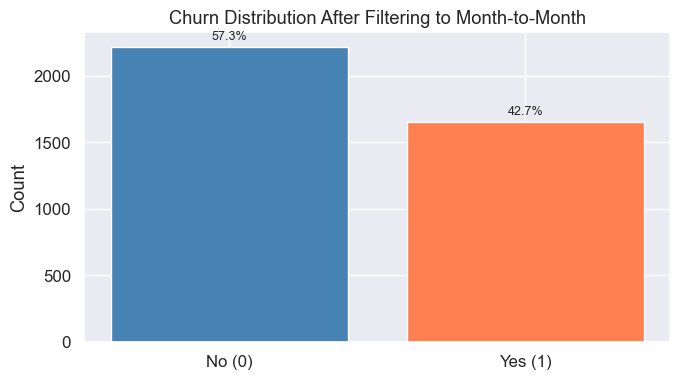

In [8]:
churn_counts = dff['Churn'].value_counts()
churn_pct    = dff['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['No (0)', 'Yes (1)'], churn_counts,
              color=['steelblue', 'coral'], edgecolor='white')
for bar, pct in zip(bars, churn_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_title('Churn Distribution After Filtering to Month-to-Month')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

##  Preprocessing 

In [10]:
# Drop rows with missing values (only 11 rows from TotalCharges)
dff.dropna(inplace=True)

X = dff.drop(columns=['Churn', 'Contract'])
y = dff['Churn'].astype(int)

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f'Samples: {X.shape[0]:,} | Features: {X.shape[1]}')
print(f'Positive class (churned): {y.mean():.1%}')
print(f'\nCategorical ({len(cat_cols)}):',  ', '.join(cat_cols))
print(f'Numeric     ({len(num_cols)}):',  ', '.join(num_cols))

Samples: 3,875 | Features: 26
Positive class (churned): 42.7%

Categorical (15): gender, Partner, Dependents, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, PaperlessBilling, PaymentMethod, tenure_group
Numeric     (11): SeniorCitizen, tenure, MonthlyCharges, TotalCharges, avg_monthly, addon_services_count, is_fiber, has_multiple_services, charge_per_service, tenure_per_service, charges_diff


In [11]:

# preproc_scaled : for distance/gradient-based models (LR, KNN)
# preproc_tree   : for tree-based models (DT, RF, XGBoost) — no scaling needed

preproc_scaled = ColumnTransformer([
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]), cat_cols),
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler())
    ]), num_cols)
])

preproc_tree = ColumnTransformer([
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]), cat_cols),
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median'))
    ]), num_cols)
])

print('Preprocessors defined.')

Preprocessors defined.


##  Model Pipelines 

In [12]:
from sklearn.pipeline import Pipeline

models = {
    'Decision Tree': {
        'pipe': Pipeline([
            ('preprocess', preproc_tree),
            ('model',      DecisionTreeClassifier(random_state=42))
        ]),
        'grid': {
            'model__max_depth':         [3, 5, 8, None],
            'model__min_samples_split': [2, 10, 20],
            'model__min_samples_leaf':  [1, 5, 10],
            'model__class_weight':      [None, 'balanced']
        }
    },
    'Logistic Regression': {
        'pipe': Pipeline([
            ('preprocess', preproc_scaled),
            ('model',      LogisticRegression(max_iter=2000, solver='saga'))
        ]),
        'grid': {
            'model__C':            [0.1, 1, 3],
            'model__l1_ratio':     [0.0, 0.5, 1.0],  # 0=L2, 1=L1, 0.5=ElasticNet
            'model__class_weight': [None, 'balanced']
        }
    },
    'KNN': {
        'pipe': Pipeline([
            ('preprocess', preproc_scaled),
            ('model',      KNeighborsClassifier())
        ]),
        'grid': {
            'model__n_neighbors': [3, 5, 7, 11],
            'model__weights':     ['uniform', 'distance'],
            'model__p':           [1, 2]
        }
    },
    'Random Forest': {
        'pipe': Pipeline([
            ('preprocess', preproc_tree),
            ('model',      RandomForestClassifier(random_state=42))
        ]),
        'grid': {
            'model__n_estimators':      [100, 200],
            'model__max_depth':         [5, 10, None],
            'model__min_samples_split': [2, 10],
            'model__class_weight':      [None, 'balanced']
        }
    },
    'XGBoost': {
        'pipe': Pipeline([
            ('preprocess', preproc_tree),
            ('model',      XGBClassifier(random_state=42, eval_metric='logloss'))
        ]),
        'grid': {
            'model__n_estimators':       [100, 200],
            'model__max_depth':          [3, 5, 7],
            'model__learning_rate':      [0.01, 0.1, 0.3],
            'model__scale_pos_weight':   [1, 1.34]  # Adjusted for class imbalance (
        }
    }
}
print(f'{len(models)} model pipelines defined:', list(models.keys()))

print(f'{len(models)} model pipelines defined:', list(models.keys()))

5 model pipelines defined: ['Decision Tree', 'Logistic Regression', 'KNN', 'Random Forest', 'XGBoost']
5 model pipelines defined: ['Decision Tree', 'Logistic Regression', 'KNN', 'Random Forest', 'XGBoost']


## 7. Nested Cross-Validation & Model Selection <a id='7'></a>

We use **nested CV** to get honest, leakage-free performance estimates:
- **Outer loop** (5 folds): evaluate generalisation on held-out data
- **Inner loop** (5 folds): tune hyperparameters via GridSearchCV

Out-of-fold (OOF) probabilities are collected to build the final ROC curves.


── Decision Tree ──
  Fold 1 | AUC=0.727  F1=0.633
  Fold 2 | AUC=0.722  F1=0.586
  Fold 3 | AUC=0.682  F1=0.579
  Fold 4 | AUC=0.735  F1=0.644
  Fold 5 | AUC=0.717  F1=0.642

── Logistic Regression ──
  Fold 1 | AUC=0.737  F1=0.629
  Fold 2 | AUC=0.766  F1=0.647
  Fold 3 | AUC=0.750  F1=0.629
  Fold 4 | AUC=0.756  F1=0.612
  Fold 5 | AUC=0.761  F1=0.632

── KNN ──
  Fold 1 | AUC=0.707  F1=0.592
  Fold 2 | AUC=0.732  F1=0.625
  Fold 3 | AUC=0.693  F1=0.587
  Fold 4 | AUC=0.738  F1=0.622
  Fold 5 | AUC=0.714  F1=0.600

── Random Forest ──
  Fold 1 | AUC=0.744  F1=0.616
  Fold 2 | AUC=0.758  F1=0.599
  Fold 3 | AUC=0.738  F1=0.624
  Fold 4 | AUC=0.769  F1=0.608
  Fold 5 | AUC=0.752  F1=0.641

── XGBoost ──
  Fold 1 | AUC=0.737  F1=0.626
  Fold 2 | AUC=0.766  F1=0.671
  Fold 3 | AUC=0.733  F1=0.629
  Fold 4 | AUC=0.769  F1=0.632
  Fold 5 | AUC=0.752  F1=0.622


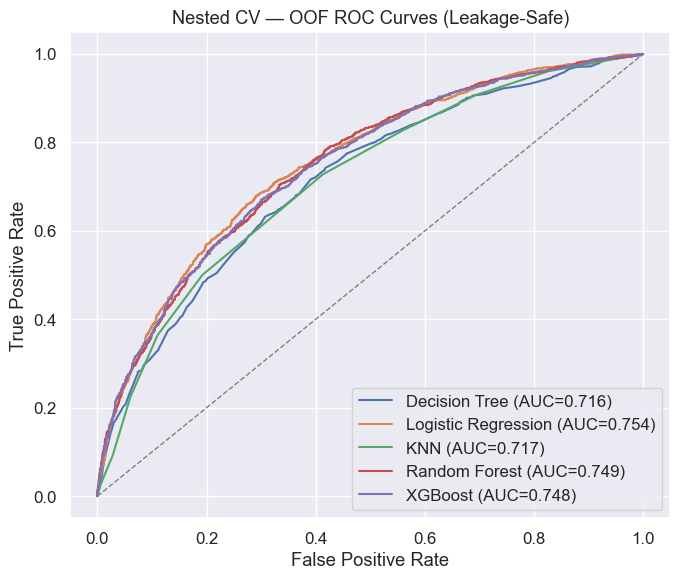

In [13]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

summary_rows        = []
inner_vs_nested_rows= []
best_params_votes   = {}
oof_probs_all       = {}   # store per-model OOF probs for threshold tuning

fig, ax = plt.subplots(figsize=(7, 6))

for name, cfg in models.items():
    print(f'\n── {name} ──')
    oof_probs    = np.zeros(len(y))
    oof_true     = y.values.copy()
    fold_metrics = []
    fold_params  = []
    inner_scores = []

    for k, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y), start=1):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        grid = GridSearchCV(cfg['pipe'], cfg['grid'],
                            cv=inner_cv, scoring='roc_auc',
                            n_jobs=-1, refit=True)
        grid.fit(X_tr, y_tr)
        inner_scores.append(grid.best_score_)
        fold_params.append(grid.best_params_)

        probs = grid.best_estimator_.predict_proba(X_te)[:, 1]
        preds = (probs >= 0.5).astype(int)
        oof_probs[te_idx] = probs

        fold_metrics.append({
            'AUC':       roc_auc_score(y_te, probs),
            'Accuracy':  accuracy_score(y_te, preds),
            'F1':        f1_score(y_te, preds),
            'Recall':    recall_score(y_te, preds),
            'Precision': precision_score(y_te, preds, zero_division=0)
        })
        print(f'  Fold {k} | AUC={fold_metrics[-1]["AUC"]:.3f}  F1={fold_metrics[-1]["F1"]:.3f}')

    # ROC curve
    fpr, tpr, _ = roc_curve(oof_true, oof_probs)
    oof_auc = roc_auc_score(oof_true, oof_probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={oof_auc:.3f})')

    oof_probs_all[name] = oof_probs.copy()

    AUCs = [m['AUC'] for m in fold_metrics]
    summary_rows.append({
        'Model':     name,
        'Mean AUC':  np.mean(AUCs),
        'Std AUC':   np.std(AUCs),
        'OOF AUC':   oof_auc,
        'Accuracy':  accuracy_score(oof_true, (oof_probs >= 0.5).astype(int)),
        'F1':        f1_score(oof_true, (oof_probs >= 0.5).astype(int)),
        'Recall':    recall_score(oof_true, (oof_probs >= 0.5).astype(int)),
        'Precision': precision_score(oof_true, (oof_probs >= 0.5).astype(int), zero_division=0)
    })

    inner_vs_nested_rows.append({
        'Model':              name,
        'Non-nested AUC':     np.mean(inner_scores),
        'Nested OOF AUC':     oof_auc,
        'Optimism Bias':      np.mean(inner_scores) - oof_auc
    })

    vote = Counter(tuple(sorted(p.items())) for p in fold_params)
    best_params_votes[name] = dict(vote.most_common(1)[0][0])

ax.plot([0, 1], [0, 1], '--', color='grey', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Nested CV — OOF ROC Curves (Leakage-Safe)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [14]:
summary_df = pd.DataFrame(summary_rows).sort_values('OOF AUC', ascending=False)
print('=== Model Performance Summary ===')
print(summary_df.set_index('Model').round(3).to_string())

print('\n=== Non-Nested vs Nested AUC (Optimism Bias) ===')
nn_df = pd.DataFrame(inner_vs_nested_rows)
print(nn_df.set_index('Model').round(3).to_string())

=== Model Performance Summary ===
                     Mean AUC  Std AUC  OOF AUC  Accuracy     F1  Recall  Precision
Model                                                                              
Logistic Regression     0.754    0.010    0.754     0.698  0.630   0.602      0.660
Random Forest           0.752    0.011    0.749     0.685  0.618   0.598      0.640
XGBoost                 0.752    0.014    0.748     0.687  0.637   0.642      0.632
KNN                     0.717    0.017    0.717     0.662  0.606   0.607      0.604
Decision Tree           0.717    0.018    0.716     0.666  0.618   0.634      0.604

=== Non-Nested vs Nested AUC (Optimism Bias) ===
                     Non-nested AUC  Nested OOF AUC  Optimism Bias
Model                                                             
Decision Tree                 0.723           0.716          0.007
Logistic Regression           0.755           0.754          0.001
KNN                           0.721           0.717         

## 8. Final Model Fitting <a id='8'></a>

In [15]:
final_models = {}
for name, cfg in models.items():
    params = {k: v for k, v in best_params_votes[name].items()}
    final_pipe = cfg['pipe'].set_params(**params)
    final_pipe.fit(X, y)
    final_models[name] = final_pipe
    print(f'{name:25s} — fitted  |  best params: {params}')

Decision Tree             — fitted  |  best params: {'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
Logistic Regression       — fitted  |  best params: {'model__C': 3, 'model__class_weight': None, 'model__l1_ratio': 0.5}
KNN                       — fitted  |  best params: {'model__n_neighbors': 11, 'model__p': 1, 'model__weights': 'uniform'}
Random Forest             — fitted  |  best params: {'model__class_weight': None, 'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 100}
XGBoost                   — fitted  |  best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__scale_pos_weight': 1.34}


## 9. Feature Importance & Interpretability <a id='9'></a>

── Decision Tree — Top 15 Features ──


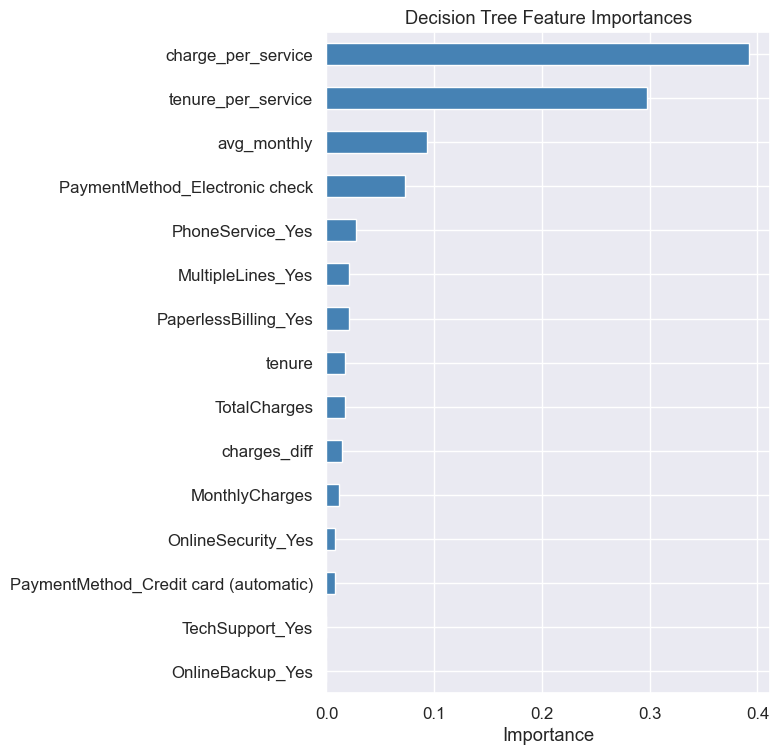

charge_per_service                       0.392363
tenure_per_service                       0.297025
avg_monthly                              0.093246
PaymentMethod_Electronic check           0.072871
PhoneService_Yes                         0.027114
MultipleLines_Yes                        0.020731
PaperlessBilling_Yes                     0.020694
tenure                                   0.017456
TotalCharges                             0.016880
charges_diff                             0.014664
MonthlyCharges                           0.011665
OnlineSecurity_Yes                       0.007671
PaymentMethod_Credit card (automatic)    0.007622
TechSupport_Yes                          0.000000
OnlineBackup_Yes                         0.000000
dtype: float64


In [16]:
def get_feature_names(preproc, X_df):
    """Extract OHE + numeric feature names from a fitted ColumnTransformer."""
    ohe      = preproc.named_transformers_['cat'].named_steps['encode']
    cat_names= ohe.get_feature_names_out(preproc.transformers_[0][2]).tolist()
    num_names= list(preproc.transformers_[1][2])
    return cat_names + num_names


def plot_top_features(importances, names, title, top_n=15, color='steelblue'):
    """Horizontal bar chart of top N features."""
    s = pd.Series(importances, index=names).sort_values(ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(8, 0.45 * top_n + 1))
    s[::-1].plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    return s


# ── Decision Tree ─────────────────────────────────────────────────────────────
tree_pipe   = final_models['Decision Tree']
tree_names  = get_feature_names(tree_pipe.named_steps['preprocess'], X)
tree_imp    = tree_pipe.named_steps['model'].feature_importances_
print('── Decision Tree — Top 15 Features ──')
dt_top = plot_top_features(tree_imp, tree_names,
                            'Decision Tree Feature Importances', color='steelblue')
print(dt_top)

── Logistic Regression — Top 15 Odds Ratios ──


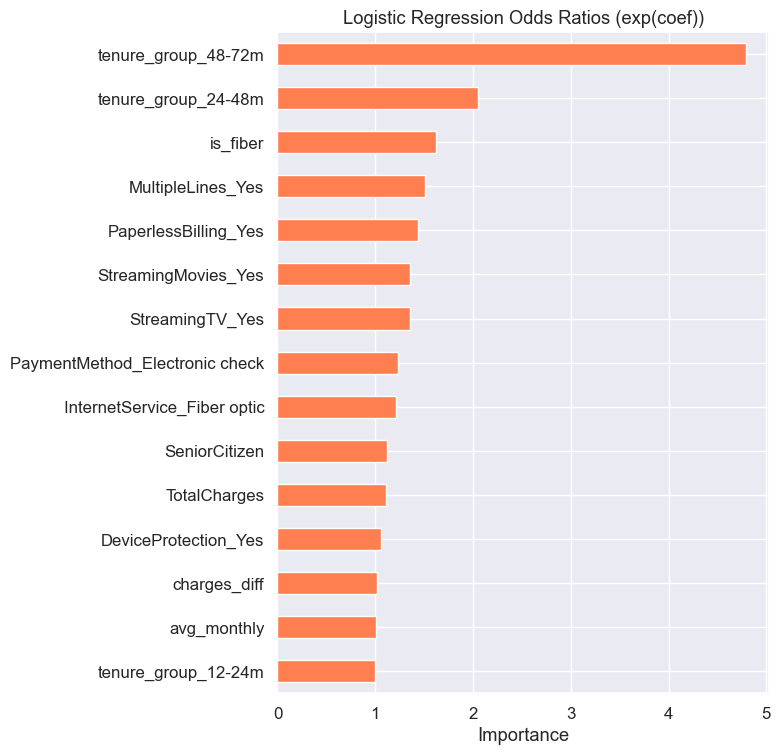

tenure_group_48-72m               4.789496
tenure_group_24-48m               2.052390
is_fiber                          1.618060
MultipleLines_Yes                 1.508320
PaperlessBilling_Yes              1.435788
StreamingMovies_Yes               1.359914
StreamingTV_Yes                   1.354815
PaymentMethod_Electronic check    1.237587
InternetService_Fiber optic       1.211170
SeniorCitizen                     1.120054
TotalCharges                      1.112818
DeviceProtection_Yes              1.059853
charges_diff                      1.018461
avg_monthly                       1.009665
tenure_group_12-24m               0.994294
dtype: float64


In [17]:
# ── Logistic Regression — Odds Ratios ────────────────────────────────────────
log_pipe   = final_models['Logistic Regression']
log_names  = get_feature_names(log_pipe.named_steps['preprocess'], X)
coefs      = log_pipe.named_steps['model'].coef_.ravel()
odds_ratios= np.exp(coefs)

print('── Logistic Regression — Top 15 Odds Ratios ──')
lr_top = plot_top_features(odds_ratios, log_names,
                            'Logistic Regression Odds Ratios (exp(coef))',
                            color='coral')
print(lr_top)

── Random Forest — Top 15 Features ──


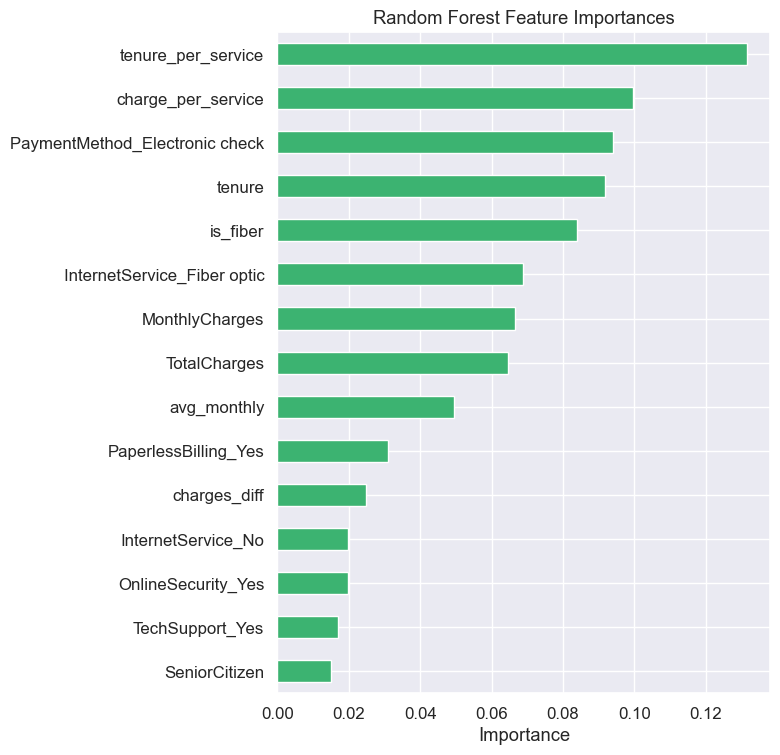

tenure_per_service                0.131594
charge_per_service                0.099691
PaymentMethod_Electronic check    0.094135
tenure                            0.091855
is_fiber                          0.084068
InternetService_Fiber optic       0.068744
MonthlyCharges                    0.066506
TotalCharges                      0.064730
avg_monthly                       0.049534
PaperlessBilling_Yes              0.031093
charges_diff                      0.024880
InternetService_No                0.019822
OnlineSecurity_Yes                0.019641
TechSupport_Yes                   0.017045
SeniorCitizen                     0.015148
dtype: float64


In [18]:
# ── Random Forest — Built-in Importances ─────────────────────────────────────
rf_pipe   = final_models['Random Forest']
rf_names  = get_feature_names(rf_pipe.named_steps['preprocess'], X)
rf_imp    = rf_pipe.named_steps['model'].feature_importances_

print('── Random Forest — Top 15 Features ──')
rf_top = plot_top_features(rf_imp, rf_names,
                            'Random Forest Feature Importances', color='mediumseagreen')
print(rf_top)

── XGBoost — Top 15 Features ──


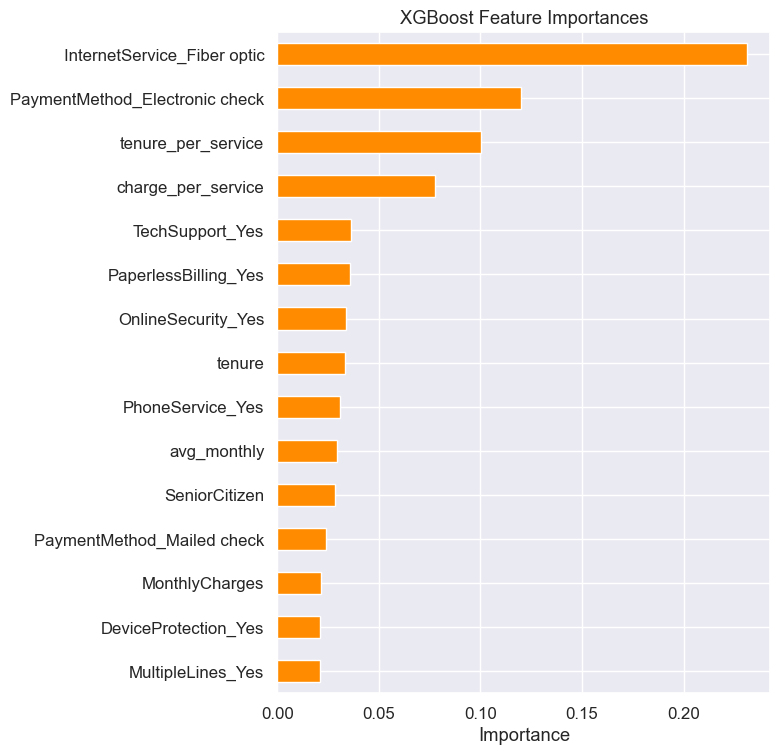

InternetService_Fiber optic       0.231222
PaymentMethod_Electronic check    0.119809
tenure_per_service                0.100342
charge_per_service                0.077700
TechSupport_Yes                   0.036015
PaperlessBilling_Yes              0.035619
OnlineSecurity_Yes                0.033989
tenure                            0.033480
PhoneService_Yes                  0.030737
avg_monthly                       0.029234
SeniorCitizen                     0.028363
PaymentMethod_Mailed check        0.023770
MonthlyCharges                    0.021468
DeviceProtection_Yes              0.021173
MultipleLines_Yes                 0.021015
dtype: float32


In [17]:
# ── XGBoost — Built-in Importances ───────────────────────────────────────────
xgb_pipe  = final_models['XGBoost']
xgb_names = get_feature_names(xgb_pipe.named_steps['preprocess'], X)
xgb_imp   = xgb_pipe.named_steps['model'].feature_importances_

print('── XGBoost — Top 15 Features ──')
xgb_top = plot_top_features(xgb_imp, xgb_names,
                             'XGBoost Feature Importances', color='darkorange')
print(xgb_top)

── KNN — Permutation Importance (Top 15) ──


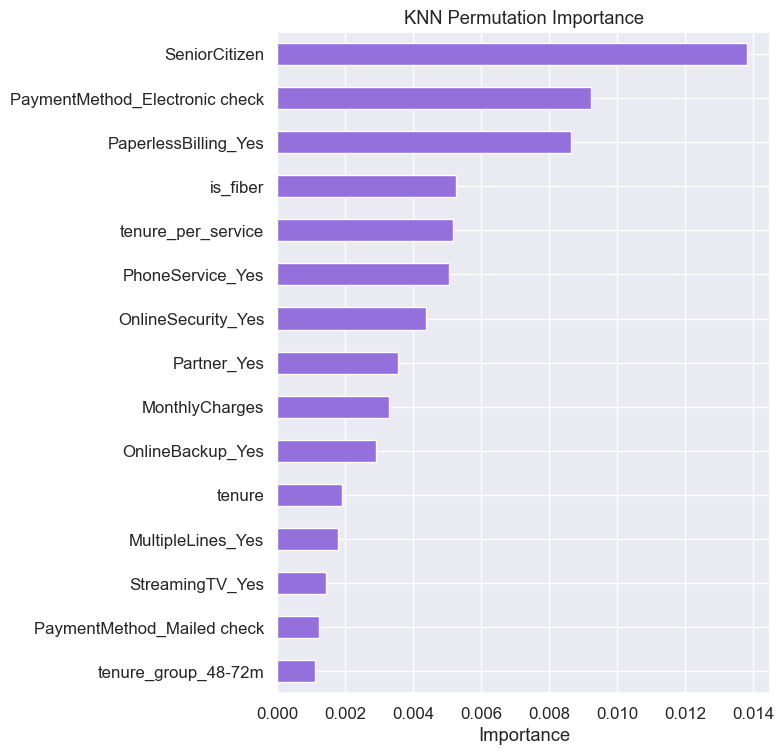

SeniorCitizen                     0.013826
PaymentMethod_Electronic check    0.009238
PaperlessBilling_Yes              0.008656
is_fiber                          0.005244
tenure_per_service                0.005181
PhoneService_Yes                  0.005054
OnlineSecurity_Yes                0.004388
Partner_Yes                       0.003560
MonthlyCharges                    0.003286
OnlineBackup_Yes                  0.002905
tenure                            0.001901
MultipleLines_Yes                 0.001790
StreamingTV_Yes                   0.001430
PaymentMethod_Mailed check        0.001226
tenure_group_48-72m               0.001119
dtype: float64


In [18]:
# ── KNN — Permutation Importance ─────────────────────────────────────────────
split       = next(iter(StratifiedKFold(n_splits=5, shuffle=True, random_state=1).split(X, y)))
X_tr_knn, X_te_knn = X.iloc[split[0]], X.iloc[split[1]]
y_tr_knn, y_te_knn = y.iloc[split[0]], y.iloc[split[1]]

knn_tmp = models['KNN']['pipe'].set_params(**best_params_votes['KNN'])
knn_tmp.fit(X_tr_knn, y_tr_knn)

X_te_enc      = knn_tmp.named_steps['preprocess'].transform(X_te_knn)
feat_names_knn= get_feature_names(knn_tmp.named_steps['preprocess'], X)
pi = permutation_importance(knn_tmp.named_steps['model'], X_te_enc, y_te_knn,
                            n_repeats=10, random_state=0, scoring='roc_auc')

print('── KNN — Permutation Importance (Top 15) ──')
knn_top = plot_top_features(pi.importances_mean, feat_names_knn,
                             'KNN Permutation Importance', color='mediumpurple')
print(knn_top)

## 10. Threshold Tuning <a id='10'></a>

For churn, **recall** (catching churners) matters more than precision. We plot Precision, Recall, and F1 across decision thresholds to find the optimal operating point.

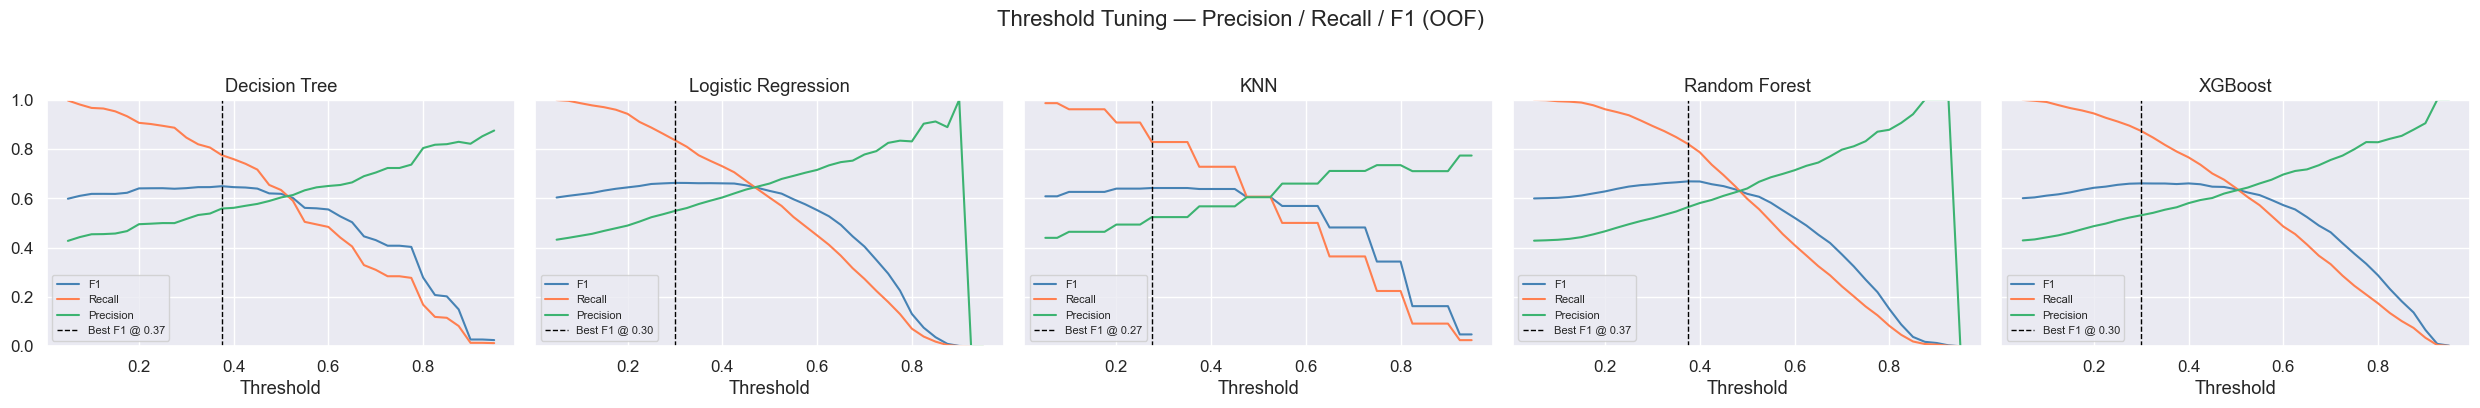

                     Best Threshold  Best F1
Model                                       
Decision Tree                 0.375    0.649
Logistic Regression           0.300    0.663
KNN                           0.275    0.642
Random Forest                 0.375    0.669
XGBoost                       0.300    0.661


In [19]:
def plot_threshold_curve(oof_true, oof_probs, name, ax):
    """Plot Precision/Recall/F1 vs decision threshold."""
    ths  = np.linspace(0.05, 0.95, 37)
    recs, pres, f1s = [], [], []
    for t in ths:
        preds = (oof_probs >= t).astype(int)
        recs.append(recall_score(oof_true,    preds, zero_division=0))
        pres.append(precision_score(oof_true, preds, zero_division=0))
        f1s.append(f1_score(oof_true,         preds, zero_division=0))
    best_t = ths[np.argmax(f1s)]
    ax.plot(ths, f1s,  label='F1',        color='steelblue')
    ax.plot(ths, recs, label='Recall',    color='coral')
    ax.plot(ths, pres, label='Precision', color='mediumseagreen')
    ax.axvline(best_t, color='black', linestyle='--', linewidth=1,
               label=f'Best F1 @ {best_t:.2f}')
    ax.set_title(f'{name}')
    ax.set_xlabel('Threshold')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    return best_t, max(f1s)


n = len(models)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True)

threshold_summary = []
for ax, (name, _) in zip(axes, models.items()):
    best_t, best_f1 = plot_threshold_curve(y.values, oof_probs_all[name], name, ax)
    threshold_summary.append({'Model': name, 'Best Threshold': best_t, 'Best F1': best_f1})

plt.suptitle('Threshold Tuning — Precision / Recall / F1 (OOF)', y=1.02)
plt.tight_layout()
plt.show()

print(pd.DataFrame(threshold_summary).set_index('Model').round(3))

## 11. Customer Lifetime Value Estimation <a id='11'></a>

**Methodology:**
- CLV is estimated using the best-performing model's predicted churn probability.
- Expected remaining lifespan = `1 / churn_probability` (geometric distribution of churn).
- CLV = `Monthly Charges × Expected Lifespan × Annual Discount Factor`
- **Discount rate:** 10% annually (standard telecoms assumption)

In [20]:
# Use best model by OOF AUC
best_model_name = summary_df.iloc[0]['Model']
print(f'Using best model: {best_model_name}')

best_model = final_models[best_model_name]
churn_proba = best_model.predict_proba(X)[:, 1]

# Build CLV table
clv_df = X[['MonthlyCharges', 'tenure']].copy()
clv_df['churn_probability'] = churn_proba
clv_df['retention_probability'] = 1 - churn_proba

# --- Revised CLV proxy: based on observed revenue, not churn-probability lifespan ---
clv_df['CLV'] = clv_df['MonthlyCharges'] * clv_df['tenure']

# --- Sensitivity analysis: effect of monthly charge changes on CLV ---
clv_df['CLV_if_charge_up_5pct'] = clv_df['MonthlyCharges'] * 1.05 * clv_df['tenure']
clv_df['CLV_if_charge_down_5pct'] = clv_df['MonthlyCharges'] * 0.95 * clv_df['tenure']

clv_df['CLV_change_up_5pct'] = clv_df['CLV_if_charge_up_5pct'] - clv_df['CLV']
clv_df['CLV_change_down_5pct'] = clv_df['CLV_if_charge_down_5pct'] - clv_df['CLV']

# Value segments based on revised CLV
clv_df['CLV_Segment'] = pd.cut(
    clv_df['CLV'],
    bins=[0, 200, 600, 1500, np.inf],
    labels=['Low', 'Medium', 'High', 'Premium']
)

clv_df['Churn_Label'] = y.values

print(
    clv_df[
        ['MonthlyCharges', 'tenure', 'churn_probability', 'CLV',
         'CLV_if_charge_up_5pct', 'CLV_if_charge_down_5pct',
         'CLV_change_up_5pct', 'CLV_change_down_5pct']
    ].describe().round(2)
)

Using best model: Logistic Regression
       MonthlyCharges   tenure  churn_probability      CLV  \
count         3875.00  3875.00            3875.00  3875.00   
mean            66.40    18.04               0.43  1370.12   
std             26.93    17.69               0.22  1612.88   
min             18.75     1.00               0.01    18.85   
25%             45.85     3.00               0.23   160.25   
50%             73.25    12.00               0.41   686.25   
75%             88.88    29.00               0.62  2072.30   
max            117.45    72.00               0.90  8128.80   

       CLV_if_charge_up_5pct  CLV_if_charge_down_5pct  CLV_change_up_5pct  \
count                3875.00                  3875.00             3875.00   
mean                 1438.62                  1301.61               68.51   
std                  1693.53                  1532.24               80.64   
min                    19.79                    17.91                0.94   
25%               

In [21]:
clv_df.head()

,MonthlyCharges,tenure,churn_probability,retention_probability,CLV,CLV_if_charge_up_5pct,CLV_if_charge_down_5pct,CLV_change_up_5pct,CLV_change_down_5pct,CLV_Segment,Churn_Label
0,29.85,1,0.691335,0.308665,29.85,31.3425,28.3575,1.4925,-1.4925,Low,0
2,53.85,2,0.287374,0.712626,107.70,113.0850,102.3150,5.3850,-5.3850,Low,1
4,70.70,2,0.727034,0.272966,141.40,148.4700,134.3300,7.0700,-7.0700,Low,1
5,99.65,8,0.812839,0.187161,797.20,837.0600,757.3400,39.8600,-39.8600,High,1
6,89.10,22,0.401558,0.598442,1960.20,2058.2100,1862.1900,98.0100,-98.0100,Premium,0


In [22]:
# ── Segment Summary ───────────────────────────────────────────────────────────
seg_summary = clv_df.groupby('CLV_Segment', observed=True).agg(
    Num_Customers        = ('CLV', 'count'),
    Avg_CLV              = ('CLV', 'mean'),
    Total_CLV            = ('CLV', 'sum'),
    Avg_Monthly_Charges  = ('MonthlyCharges', 'mean'),
    Avg_Churn_Prob       = ('churn_probability', 'mean'),
    Avg_Tenure_Months    = ('tenure', 'mean')
).round(2)

print('CLV Segment Summary:')
print(seg_summary.to_string())

CLV Segment Summary:
             Num_Customers  Avg_CLV   Total_CLV  Avg_Monthly_Charges  Avg_Churn_Prob  Avg_Tenure_Months
CLV_Segment                                                                                            
Low                   1091    82.39    89886.95                47.12            0.48               2.11
Medium                 741   373.14   276496.20                58.35            0.46               8.30
High                   778   998.76   777034.30                69.44            0.43              16.43
Premium               1265  3293.11  4165778.30                85.86            0.35              38.46


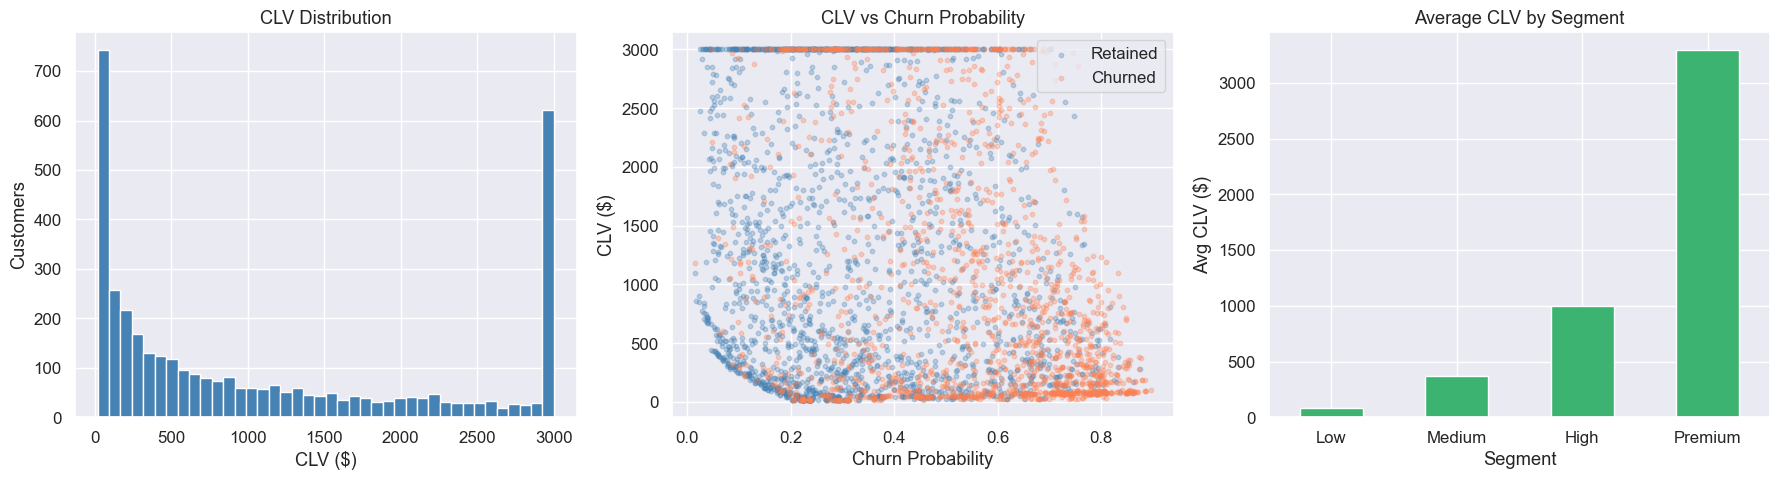

In [23]:
# ── CLV Visualisations ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. CLV distribution
axes[0].hist(clv_df['CLV'].clip(upper=3000), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('CLV Distribution')
axes[0].set_xlabel('CLV ($)')
axes[0].set_ylabel('Customers')

# 2. CLV vs Churn Probability
for label, color in [(0, 'steelblue'), (1, 'coral')]:
    mask = clv_df['Churn_Label'] == label
    axes[1].scatter(clv_df.loc[mask, 'churn_probability'],
                    clv_df.loc[mask, 'CLV'].clip(upper=3000),
                    alpha=0.3, color=color, s=10,
                    label='Churned' if label else 'Retained')
axes[1].set_title('CLV vs Churn Probability')
axes[1].set_xlabel('Churn Probability')
axes[1].set_ylabel('CLV ($)')
axes[1].legend()

# 3. Avg CLV by Segment
seg_summary['Avg_CLV'].plot(kind='bar', ax=axes[2],
                             color='mediumseagreen', edgecolor='white')
axes[2].set_title('Average CLV by Segment')
axes[2].set_xlabel('Segment')
axes[2].set_ylabel('Avg CLV ($)')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [24]:
# ── High-Value At-Risk Customers ──────────────────────────────────────────────

print('=== Churn Probability Distribution ===')
print(clv_df['churn_probability'].describe().round(3))

print('\n=== CLV Distribution ===')
print(clv_df['CLV'].describe().round(2))

print('\n=== CLV Segment Counts ===')
print(clv_df['CLV_Segment'].value_counts())

print('\n=== Customers above churn thresholds ===')
for t in [0.5, 0.4, 0.3, 0.2]:
    n = (clv_df['churn_probability'] >= t).sum()
    print(f'  churn_prob >= {t}: {n:,} customers ({n/len(clv_df):.1%})')

=== Churn Probability Distribution ===
count    3875.000
mean        0.425
std         0.224
min         0.015
25%         0.234
50%         0.414
75%         0.615
max         0.895
Name: churn_probability, dtype: float64

=== CLV Distribution ===
count    3875.00
mean     1370.12
std      1612.88
min        18.85
25%       160.25
50%       686.25
75%      2072.30
max      8128.80
Name: CLV, dtype: float64

=== CLV Segment Counts ===
CLV_Segment
Premium    1265
Low        1091
High        778
Medium      741
Name: count, dtype: int64

=== Customers above churn thresholds ===
  churn_prob >= 0.5: 1,507 customers (38.9%)
  churn_prob >= 0.4: 2,000 customers (51.6%)
  churn_prob >= 0.3: 2,493 customers (64.3%)
  churn_prob >= 0.2: 3,153 customers (81.4%)


In [25]:
# ── Fix: Segment by MonthlyCharges (independent value signal) ────────────────

mq25 = clv_df['MonthlyCharges'].quantile(0.25)
mq50 = clv_df['MonthlyCharges'].quantile(0.50)
mq75 = clv_df['MonthlyCharges'].quantile(0.75)

clv_df['Value_Segment'] = pd.cut(
    clv_df['MonthlyCharges'],
    bins=[0, mq25, mq50, mq75, np.inf],
    labels=['Low', 'Medium', 'High', 'Premium'],
    include_lowest=True
)

print(f'Monthly Charges bins:')
print(f'  Low:     $0 – ${mq25:.0f}')
print(f'  Medium:  ${mq25:.0f} – ${mq50:.0f}')
print(f'  High:    ${mq50:.0f} – ${mq75:.0f}')
print(f'  Premium: ${mq75:.0f}+')

# At-risk: high monthly spend + high churn probability
CHURN_THRESHOLD = clv_df['churn_probability'].quantile(0.70)
high_risk_mask  = clv_df['churn_probability'] >= CHURN_THRESHOLD
high_value_mask = clv_df['Value_Segment'].isin(['High', 'Premium'])

clv_df['at_risk'] = (high_risk_mask & high_value_mask).astype(int)
at_risk = clv_df[clv_df['at_risk'] == 1]

print(f'\nChurn threshold (70th pct):  {CHURN_THRESHOLD:.3f}')
print(f'High risk customers:         {high_risk_mask.sum():,}')
print(f'High/Premium value customers:{high_value_mask.sum():,}')
print(f'Both conditions met:         {(high_risk_mask & high_value_mask).sum():,}')

print(f'\n=== At-Risk Summary ===')
print(f'High-Value At-Risk Customers : {len(at_risk):,}')
print(f'Total Monthly Revenue at Risk: ${at_risk["MonthlyCharges"].sum():,.0f}')
print(f'Average Monthly Charges      : ${at_risk["MonthlyCharges"].mean():,.2f}')
print(f'Average Churn Probability    : {at_risk["churn_probability"].mean():.1%}')
print(f'Average Tenure (months)      : {at_risk["tenure"].mean():.1f}')

print('\n=== Risk × Value Segment Breakdown ===')
clv_df['risk_label'] = np.where(high_risk_mask, 'High Risk', 'Low Risk')
print(pd.crosstab(clv_df['Value_Segment'], clv_df['risk_label'],
                  values=clv_df['MonthlyCharges'], aggfunc='count', margins=True))

Monthly Charges bins:
  Low:     $0 – $46
  Medium:  $46 – $73
  High:    $73 – $89
  Premium: $89+

Churn threshold (70th pct):  0.574
High risk customers:         1,163
High/Premium value customers:1,936
Both conditions met:         883

=== At-Risk Summary ===
High-Value At-Risk Customers : 883
Total Monthly Revenue at Risk: $76,990
Average Monthly Charges      : $87.19
Average Churn Probability    : 71.2%
Average Tenure (months)      : 9.6

=== Risk × Value Segment Breakdown ===
risk_label     High Risk  Low Risk   All
Value_Segment                           
Low                   81       892   973
Medium               199       767   966
High                 494       473   967
Premium              389       580   969
All                 1163      2712  3875


In [26]:

print()
print(clv_df['Value_Segment'].dtype)
print(clv_df['Value_Segment'].unique())
print()
print(clv_df[['MonthlyCharges', 'churn_probability', 'Value_Segment', 'risk_label']].head(20))



category
['Low', 'Medium', 'Premium', 'High']
Categories (4, object): ['Low' < 'Medium' < 'High' < 'Premium']

    MonthlyCharges  churn_probability Value_Segment risk_label
0            29.85           0.691335           Low  High Risk
2            53.85           0.287374        Medium   Low Risk
4            70.70           0.727034        Medium  High Risk
5            99.65           0.812839       Premium  High Risk
6            89.10           0.401558       Premium   Low Risk
7            29.75           0.316012           Low   Low Risk
8           104.80           0.622461       Premium  High Risk
10           49.95           0.180063        Medium   Low Risk
13          103.70           0.464124       Premium   Low Risk
14          105.50           0.460018       Premium   Low Risk
18           55.20           0.152482        Medium   Low Risk
19           90.05           0.468448       Premium   Low Risk
20           39.65           0.804050           Low  High Risk
22    

In [27]:
# Force string conversion before filtering
clv_df['Value_Segment_str'] = clv_df['Value_Segment'].astype(str)

high_risk_mask  = clv_df['churn_probability'] >= CHURN_THRESHOLD
high_value_mask = clv_df['Value_Segment_str'].isin(['High', 'Premium'])

print(f'High risk:   {high_risk_mask.sum()}')
print(f'High value:  {high_value_mask.sum()}')
print(f'Overlap:     {(high_risk_mask & high_value_mask).sum()}')

High risk:   1163
High value:  1936
Overlap:     883


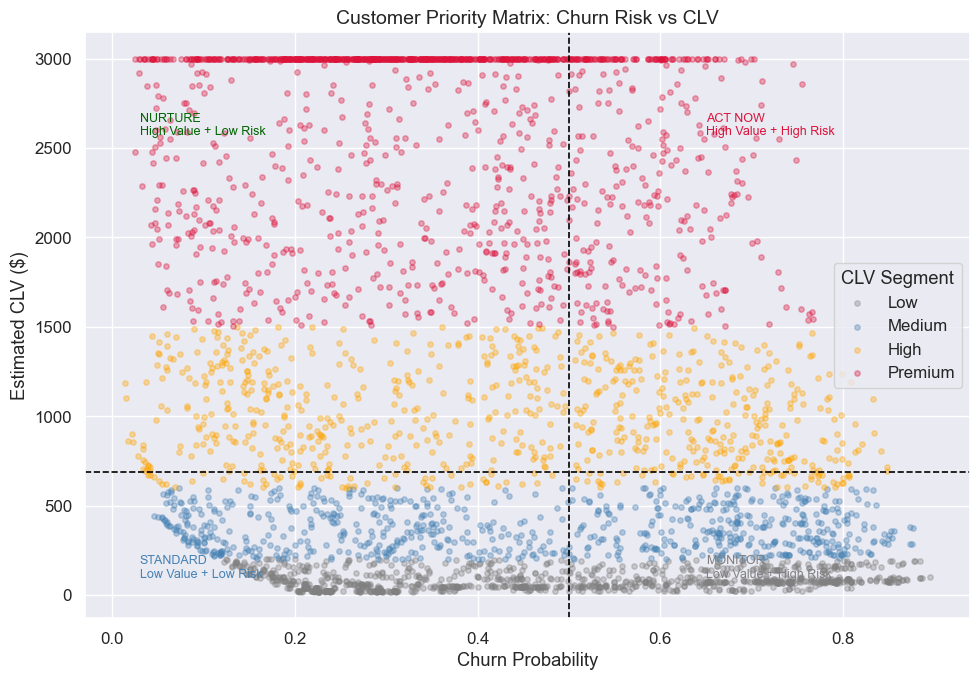

In [28]:
# ── Priority Matrix ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

colors = {'Low': 'grey', 'Medium': 'steelblue', 'High': 'orange', 'Premium': 'crimson'}
for seg, grp in clv_df.groupby('CLV_Segment', observed=True):
    ax.scatter(grp['churn_probability'],
               grp['CLV'].clip(upper=3000),
               label=seg, alpha=0.35,
               color=colors[seg], s=15)

clv_median = clv_df['CLV'].median()
ax.axvline(x=0.5,       color='black', linestyle='--', linewidth=1.2)
ax.axhline(y=clv_median, color='black', linestyle='--', linewidth=1.2)

ax.text(0.65, 2700, 'ACT NOW\nHigh Value + High Risk',  fontsize=9, color='crimson',    va='top')
ax.text(0.65, 80,   'MONITOR\nLow Value + High Risk',   fontsize=9, color='grey',       va='bottom')
ax.text(0.03, 2700, 'NURTURE\nHigh Value + Low Risk',   fontsize=9, color='darkgreen',  va='top')
ax.text(0.03, 80,   'STANDARD\nLow Value + Low Risk',   fontsize=9, color='steelblue',  va='bottom')

ax.set_title('Customer Priority Matrix: Churn Risk vs CLV', fontsize=14)
ax.set_xlabel('Churn Probability')
ax.set_ylabel('Estimated CLV ($)')
ax.legend(title='CLV Segment', loc='center right')
plt.tight_layout()
plt.show()

## 12. Business Recommendations <a id='12'></a>

### What the Model Tells Us

The top drivers of churn, consistently across models, are:
1. **Contract type** — Month-to-month customers churn at ~3× the rate of two-year subscribers.
2. **Tenure** — The first 12 months are the highest-risk window; customers who survive year 1 are far less likely to leave.
3. **Internet service type** — Fiber optic users churn significantly more than DSL or no-internet users, likely due to pricing or perceived value.
4. **Lack of add-on services** — Customers with few add-ons have lower stickiness.
5. **Monthly charges** — Higher charges, particularly without a long-term contract, increase churn risk.

---

### Priority Action Framework

| Quadrant | Customer Profile | Recommended Action | Expected ROI |
|---|---|---|---|
| 🚨 **Act Now** | High/Premium CLV + Churn Prob ≥ 50% | Proactive outreach: loyalty discount, contract upgrade offer, dedicated support call | High — protecting large revenue |
| 💎 **Nurture** | High/Premium CLV + Churn Prob < 50% | Early renewal incentives, upsell premium bundles, VIP reward programme | Medium — prevent future risk |
| 📊 **Monitor** | Low CLV + Churn Prob ≥ 50% | Low-cost automated retention (email/SMS campaigns) — do not over-invest | Low — limited revenue impact |
| 📌 **Grow** | Low CLV + Churn Prob < 50% | Cross-sell add-on services to increase monthly spend and stickiness | Medium — CLV growth opportunity |

---

### Specific Tactical Levers

**Contract conversion (highest impact)**  
Month-to-month customers flagged at risk should receive a targeted offer to switch to a 1- or 2-year contract at a modest discount. Even a 10% price concession is well worth retaining a Premium CLV customer.

**Onboarding programme for new customers**  
Since months 0–12 are the critical churn window, a structured onboarding sequence (welcome call, check-in at month 3, bundle offer at month 6) can materially reduce early churn.

**Fiber optic investigation**  
The disproportionately high churn among Fiber optic users warrants a root-cause investigation — is it pricing, service quality, or competitive alternatives? A targeted satisfaction survey or pricing review for this segment is recommended.

**Service bundling incentives**  
Customers with fewer than 3 add-on services and a high churn probability are strong candidates for bundled package promotions (e.g., combining streaming + security + tech support at a discount).

**Model operationalisation**  
- Score all customers monthly using the deployed model.
- Push the top 200–300 at-risk High/Premium customers directly into the CRM as a prioritised call list for the retention team.
- Track retained revenue per intervention to calculate actual retention ROI and refine threshold and targeting over time.